In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All basic libraries imported successfully!")



All basic libraries imported successfully!


In [6]:
import zipfile
import pandas as pd

zip_path = "../data/csv/iris.csv.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Files inside ZIP:")
    print(zip_ref.namelist())

Files inside ZIP:
['Index', 'bezdekIris.data', 'iris.data', 'iris.names']


In [7]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print(zip_ref.namelist())

['Index', 'bezdekIris.data', 'iris.data', 'iris.names']


In [8]:
# Read the Iris dataset from the ZIP archive

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    with zip_ref.open("iris.data") as file:
        df = pd.read_csv(
            file,
            header=None,
            names=[
                "sepal_length",
                "sepal_width",
                "petal_length",
                "petal_width",
                "species"
            ]
        )

print("Iris dataset loaded successfully!")
print("\nFirst 5 rows:")
display(df.head())

Iris dataset loaded successfully!

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
import os

print(os.getcwd())

c:\Users\mahat\Documents\NLP\Assignment_01\notebooks


Format: JPEG
Size: (2048, 1024)
Mode: RGB


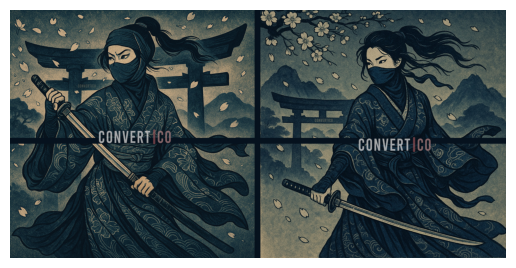

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("../data/images/convertico-ninja-girl-jpg.jpg")

print("Format:", img.format)
print("Size:", img.size)
print("Mode:", img.mode)

plt.imshow(img)
plt.axis("off")
plt.show()

In [3]:
import openpyxl
print("openpyxl is working")

openpyxl is working


First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Shape: (541909, 8)
Number of dimensions: 2
Number of rows: 541909
Number of columns: 8

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


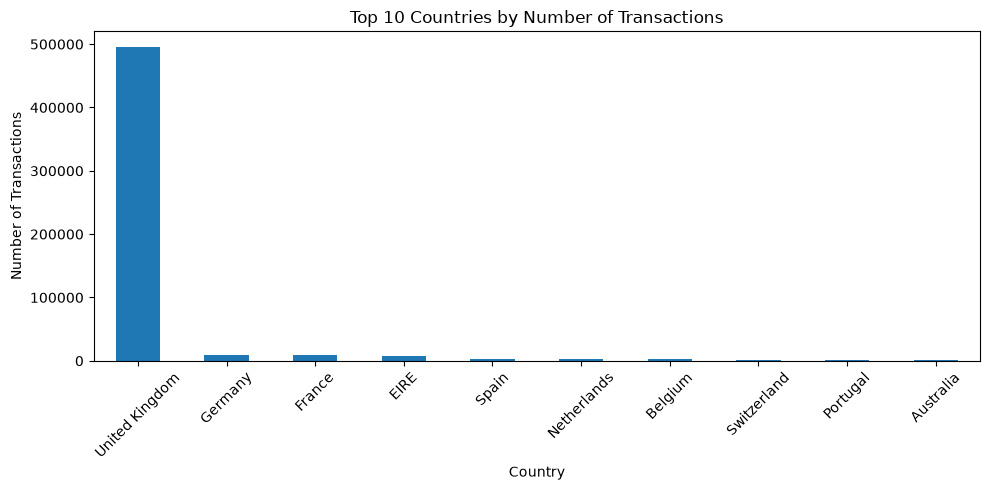

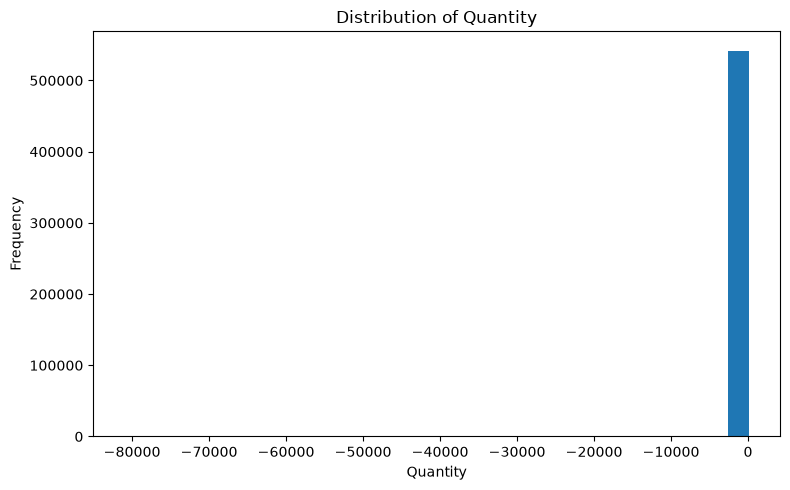

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Read Excel file
file_path = "../data/xlsx/Online Retail.xlsx"
df = pd.read_excel(file_path)

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Properties
print("Shape:", df.shape)
print("Number of dimensions:", df.ndim)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

# Bar graph - Top 10 countries
country_counts = df["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
country_counts.plot(kind="bar")
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Histogram - Quantity
plt.figure(figsize=(8, 5))
df["Quantity"].clip(upper=100).plot(kind="hist", bins=30)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [7]:
import json
import pandas as pd

# Path to JSON file
file_path = "../data/json/restaurant.json"

# Read the complete file
with open(file_path, "r", encoding="utf-8") as file:
    text = file.read().strip()

# Try to parse as a normal JSON file first
try:
    data = json.loads(text)
    print("JSON format: Standard JSON")

# If there are multiple JSON objects
except json.JSONDecodeError:
    print("JSON format: Multiple JSON records")

    decoder = json.JSONDecoder()
    data = []
    position = 0

    while position < len(text):
        # Skip whitespace
        while position < len(text) and text[position].isspace():
            position += 1

        if position >= len(text):
            break

        obj, end_position = decoder.raw_decode(text, position)
        data.append(obj)
        position = end_position

# --------------------------------
# Display basic properties
# --------------------------------

print("\nData type:", type(data))

if isinstance(data, list):
    print("Number of records:", len(data))

elif isinstance(data, dict):
    print("Number of keys:", len(data))

# --------------------------------
# Display JSON data
# --------------------------------

print("\nJSON Data:")

if isinstance(data, list):
    for i, item in enumerate(data[:5]):
        print(f"\nRecord {i + 1}:")
        print(json.dumps(item, indent=4))

else:
    print(json.dumps(data, indent=4))

# --------------------------------
# Convert JSON to DataFrame
# --------------------------------

if isinstance(data, list):
    json_df = pd.json_normalize(data)

elif isinstance(data, dict):
    json_df = pd.json_normalize([data])

else:
    json_df = None

# --------------------------------
# Display DataFrame properties
# --------------------------------

if json_df is not None:

    print("\nDataFrame:")
    display(json_df.head())

    print("\nShape:", json_df.shape)
    print("Dimensions:", json_df.ndim)
    print("Number of rows:", len(json_df))
    print("Number of columns:", len(json_df.columns))

    print("\nColumns:")
    print(json_df.columns.tolist())

JSON format: Multiple JSON records

Data type: <class 'list'>
Number of records: 2548

JSON Data:

Record 1:
{
    "URL": "http://www.just-eat.co.uk/restaurants-cn-chinese-cardiff/menu",
    "_id": {
        "$oid": "55f14312c7447c3da7051b26"
    },
    "address": "228 City Road",
    "address line 2": "Cardiff",
    "name": ".CN Chinese",
    "outcode": "CF24",
    "postcode": "3JH",
    "rating": 5,
    "type_of_food": "Chinese"
}

Record 2:
{
    "URL": "http://www.just-eat.co.uk/restaurants-atthai-ss9/menu",
    "_id": {
        "$oid": "55f14312c7447c3da7051b27"
    },
    "address": "376 Rayleigh Road",
    "address line 2": "Essex",
    "name": "@ Thai",
    "outcode": "SS9",
    "postcode": "5PT",
    "rating": 5.5,
    "type_of_food": "Thai"
}

Record 3:
{
    "URL": "http://www.just-eat.co.uk/restaurants-atthairestaurant/menu",
    "_id": {
        "$oid": "55f14312c7447c3da7051b28"
    },
    "address": "30 Greyhound Road Hammersmith",
    "address line 2": "London",
    "na

,URL,address,address line 2,name,outcode,postcode,rating,type_of_food,_id.$oid
0,http://www.just-eat.co.uk/restaurants-cn-chine...,228 City Road,Cardiff,.CN Chinese,CF24,3JH,5,Chinese,55f14312c7447c3da7051b26
1,http://www.just-eat.co.uk/restaurants-atthai-s...,376 Rayleigh Road,Essex,@ Thai,SS9,5PT,5.5,Thai,55f14312c7447c3da7051b27
2,http://www.just-eat.co.uk/restaurants-atthaire...,30 Greyhound Road Hammersmith,London,@ Thai Restaurant,W6,8NX,4.5,Thai,55f14312c7447c3da7051b28
3,http://www.just-eat.co.uk/restaurants-atthaire...,30 Greyhound Road Hammersmith,London,@ Thai Restaurant,W6,8NX,4.5,Thai,55f14312c7447c3da7051b29
4,http://www.just-eat.co.uk/restaurants-indianco...,9 Broughton Hall Road,Broughton,@Indian.com,CH4,0QR,6,Curry,55f14312c7447c3da7051b2a



Shape: (2548, 9)
Dimensions: 2
Number of rows: 2548
Number of columns: 9

Columns:
['URL', 'address', 'address line 2', 'name', 'outcode', 'postcode', 'rating', 'type_of_food', '_id.$oid']


Number of characters: 728846
Number of words: 127377
Number of lines: 14537

First 500 characters:
*** START OF THE PROJECT GUTENBERG EBOOK 1342 ***




                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                             RUSKIN HOUSE
                                   ]

                            [Illustration:

               _Reading Jane’s Letters._      _Chap 34._
                                   ]




         

Top 20 most frequent words:
the : 4658
to : 4323
of : 3842
and : 3763
her : 2260
i : 2098
a : 2036
in : 1991
was : 1871
she : 1732
that : 1605
it : 1588
not : 1492
he : 1347
you : 1342
his : 1289
be : 1263
as : 1228
had : 1181
with : 1102


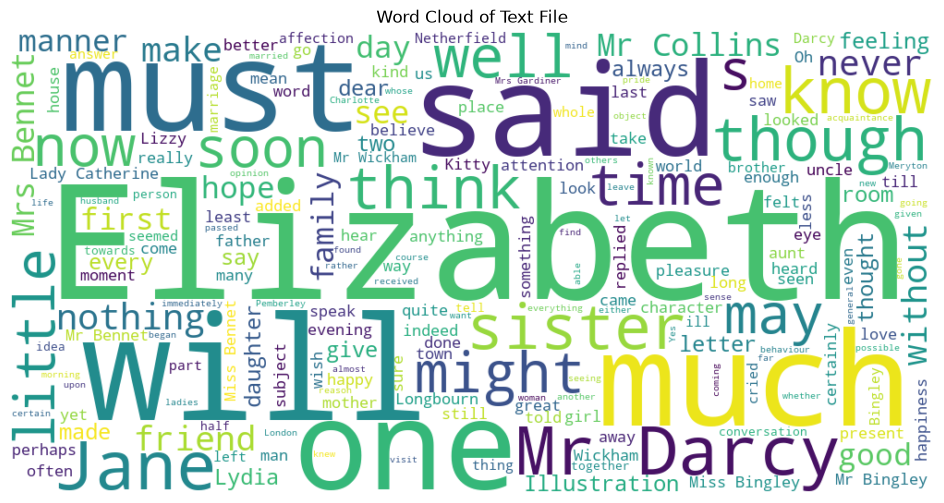

In [8]:
from collections import Counter
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Read text file
file_path = "../data/text/1342-0.txt"

with open(file_path, "r", encoding="utf-8") as file:
    text = file.read()

# Properties
print("Number of characters:", len(text))
print("Number of words:", len(text.split()))
print("Number of lines:", len(text.splitlines()))

print("\nFirst 500 characters:")
print(text[:500])

# Clean text
words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

# Word frequency
word_frequency = Counter(words)

print("\nTop 20 most frequent words:")
for word, count in word_frequency.most_common(20):
    print(word, ":", count)

# Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Text File")
plt.show()

In [9]:
from IPython.display import Video, display
import os

file_path = "../data/video/video.mp4"

# File properties
file_size = os.path.getsize(file_path)

print("File name:", os.path.basename(file_path))
print("File size:", file_size, "bytes")
print("File extension:", os.path.splitext(file_path)[1])

# Display video player
display(Video(file_path, embed=True))

File name: video.mp4
File size: 2004344 bytes
File extension: .mp4


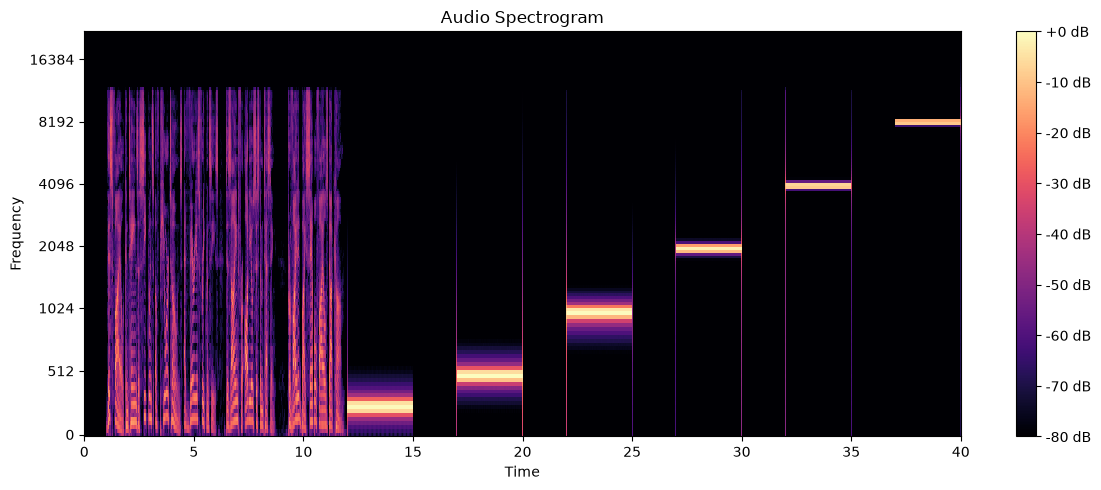

In [15]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Create Mel spectrogram
spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sample_rate
)

# Convert power spectrogram to decibels
spectrogram_db = librosa.power_to_db(
    spectrogram,
    ref=np.max
)

# Display spectrogram
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    spectrogram_db,
    sr=sample_rate,
    x_axis="time",
    y_axis="mel"
)

plt.title("Audio Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()